# 📊 Amazon Sales Data Analysis Dashboard

## Introduction

This project presents an exploratory and analytical study of the Amazon Sales Data dataset. The dataset contains 3,203 rows and 10 columns, including Order ID, Order Date, Ship Date, EmailID, Geography, Category, Product Name, Sales, Quantity, and Profit.

The dataset used in this project was sourced from the Kaggle platform, which provides publicly available datasets for data analysis and machine learning projects.

The objective of this analysis is to evaluate overall business performance by examining key metrics such as sales, quantity sold, and profit. The project explores product performance, customer purchasing patterns, category-wise profitability, regional sales distribution, and time-based sales trends.

Using Python for data analysis and visualization, this dashboard provides meaningful insights that help identify top-performing products, profitable categories, and potential areas for improvement. The analysis aims to support data-driven decision making that can enhance business growth and operational efficiency.

## 🎯 Project Objective

- To perform exploratory data analysis (EDA) on Amazon sales data
- To identify top-performing product categories and segments
- To analyze sales and profit distribution across different regions
- To evaluate time-based trends in sales performance
- To create effective visualizations using bar charts and graphs
- To generate actionable insights for business improvement

## 📊 Case Studies

1.  What are the total Sales, Quantity, and Profit?
2.  Which are the Top 10 highest selling products?
3.  Which category generates the highest Profit?
4.  State-wise Sales and Profit Analysis
5.  What is the Monthly Sales Trend?
6.  What is the Year-wise performance of Sales and Profit?
7.  Which top 10 customers placed the highest number of orders?
8.  Which products have negative profit (loss-making)?
9.  What is the Average Order Value (AOV)?
10. How many repeat customers do we have?
11. Show top 10 categories which sells the most quantity?
12. Calculate Profit Margin % for each product?
13. Which is the most profitable month?
14. What is the average shipping time?
15. Does Shipping Time impact Profit? (Correlation Analysis)

## 📚 Libraries Used in the project 

To begin the project, we will import four important Python libraries:

- Pandas: Used for data loading, cleaning, manipulation, and exploratory data analysis (EDA)
- NumPy : Used for numerical operations and handling arrays
- Matplotlib: Used for creating basic plots and visual representations of data
- Seaborn: Used for advanced statistical visualizations and enhancing the appearance of charts


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel(r"C:\Users\NITIN\Desktop\Python Notes\Python Case Study Data.xlsx")

In [3]:
df

,Order ID,Order Date,Ship Date,EmailID,Geography,Category,Product Name,Sales,Quantity,Profit
0,CA-2021-138688,2021-06-13,2021-06-17,DarrinVanHuff@gmail.com,"United States,Los Angeles,California",Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,6.8714
1,CA-2019-115812,2019-06-09,2019-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,14.1694
2,CA-2019-115812,2019-06-09,2019-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Art,Newell 322,7.280,4,1.9656
3,CA-2019-115812,2019-06-09,2019-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Phones,Mitel 5320 IP Phone VoIP phone,907.152,4,90.7152
4,CA-2019-115812,2019-06-09,2019-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Binders,DXL Angle-View Binders with Locking Rings by S...,18.504,3,5.7825
...,...,...,...,...,...,...,...,...,...,...
3198,CA-2021-125794,2021-09-30,2021-10-04,MarisLaWare@gmail.com,"United States,Los Angeles,California",Accessories,Memorex Mini Travel Drive 64 GB USB 2.0 Flash ...,36.240,1,15.2208
3199,CA-2022-121258,2022-02-27,2022-03-04,DaveBrooks@gmail.com,"United States,Costa Mesa,California",Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,15.6332
3200,CA-2022-121258,2022-02-27,2022-03-04,DaveBrooks@gmail.com,"United States,Costa Mesa,California",Phones,Aastra 57i VoIP phone,258.576,2,19.3932
3201,CA-2022-121258,2022-02-27,2022-03-04,DaveBrooks@gmail.com,"United States,Costa Mesa,California",Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,13.3200


In [4]:
df.isnull().sum()

Order ID        0
Order Date      1
Ship Date       0
EmailID         1
Geography       0
Category        0
Product Name    1
Sales           0
Quantity        0
Profit          0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3203 entries, 0 to 3202
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order ID      3203 non-null   object        
 1   Order Date    3202 non-null   datetime64[ns]
 2   Ship Date     3203 non-null   datetime64[ns]
 3   EmailID       3202 non-null   object        
 4   Geography     3203 non-null   object        
 5   Category      3203 non-null   object        
 6   Product Name  3202 non-null   object        
 7   Sales         3203 non-null   float64       
 8   Quantity      3203 non-null   int64         
 9   Profit        3203 non-null   float64       
dtypes: datetime64[ns](2), float64(2), int64(1), object(5)
memory usage: 250.4+ KB


#### Data Cleaning

In [6]:
df.dropna(subset=["Order Date" , "EmailID" , "Product Name"], inplace=True)

In [7]:
df.isnull().sum()

Order ID        0
Order Date      0
Ship Date       0
EmailID         0
Geography       0
Category        0
Product Name    0
Sales           0
Quantity        0
Profit          0
dtype: int64

In [8]:
df[["Country" , "City" , "State"]] = df["Geography"].str.split("," , expand = True)

In [9]:
df = df.drop(columns = ["Geography"])

In [10]:
df

,Order ID,Order Date,Ship Date,EmailID,Category,Product Name,Sales,Quantity,Profit,Country,City,State
0,CA-2021-138688,2021-06-13,2021-06-17,DarrinVanHuff@gmail.com,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,6.8714,United States,Los Angeles,California
1,CA-2019-115812,2019-06-09,2019-06-14,BrosinaHoffman@gmail.com,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,14.1694,United States,Los Angeles,California
2,CA-2019-115812,2019-06-09,2019-06-14,BrosinaHoffman@gmail.com,Art,Newell 322,7.280,4,1.9656,United States,Los Angeles,California
3,CA-2019-115812,2019-06-09,2019-06-14,BrosinaHoffman@gmail.com,Phones,Mitel 5320 IP Phone VoIP phone,907.152,4,90.7152,United States,Los Angeles,California
4,CA-2019-115812,2019-06-09,2019-06-14,BrosinaHoffman@gmail.com,Binders,DXL Angle-View Binders with Locking Rings by S...,18.504,3,5.7825,United States,Los Angeles,California
...,...,...,...,...,...,...,...,...,...,...,...,...
3198,CA-2021-125794,2021-09-30,2021-10-04,MarisLaWare@gmail.com,Accessories,Memorex Mini Travel Drive 64 GB USB 2.0 Flash ...,36.240,1,15.2208,United States,Los Angeles,California
3199,CA-2022-121258,2022-02-27,2022-03-04,DaveBrooks@gmail.com,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,15.6332,United States,Costa Mesa,California
3200,CA-2022-121258,2022-02-27,2022-03-04,DaveBrooks@gmail.com,Phones,Aastra 57i VoIP phone,258.576,2,19.3932,United States,Costa Mesa,California
3201,CA-2022-121258,2022-02-27,2022-03-04,DaveBrooks@gmail.com,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,13.3200,United States,Costa Mesa,California


### Case Studies

### 1. What are the total Sales, Quantity, and Profit?

In [11]:
Sales = df["Sales"].sum().round(2)
Qty = df["Quantity"].sum().round(2)
Profit = df["Profit"].sum().round(2)

In [12]:
print("The total sales is:", Sales)
print("The total quantity is:", Qty)
print("The total profit is:", Profit)

The total sales is: 725337.6
The total quantity is: 12255
The total profit is: 108374.76


### 2. Which are the Top 10 highest selling products?

In [13]:
gr = df.groupby(["Product Name"]).agg(Qty=("Quantity" , "sum")).round(2)
gr = gr.sort_values(by=["Qty"], ascending= False).head(10).reset_index()
gr

,Product Name,Qty
0,Staples,216
1,Wilson Jones Clip & Carry Folder Binder Tool f...,32
2,Cardinal EasyOpen D-Ring Binders,31
3,Eldon Shelf Savers Cubes and Bins,29
4,Vinyl Sectional Post Binders,29
5,LogitechÂ P710e Mobile Speakerphone,29
6,Memorex Micro Travel Drive 16 GB,28
7,Dana Halogen Swing-Arm Architect Lamp,28
8,4009 Highlighters by Sanford,27
9,Flat Face Poster Frame,27


C:\Users\NITIN\AppData\Local\Temp\ipykernel_16528\2223584865.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data = gr , x = "Product Name" , y = "Qty" , palette="viridis")


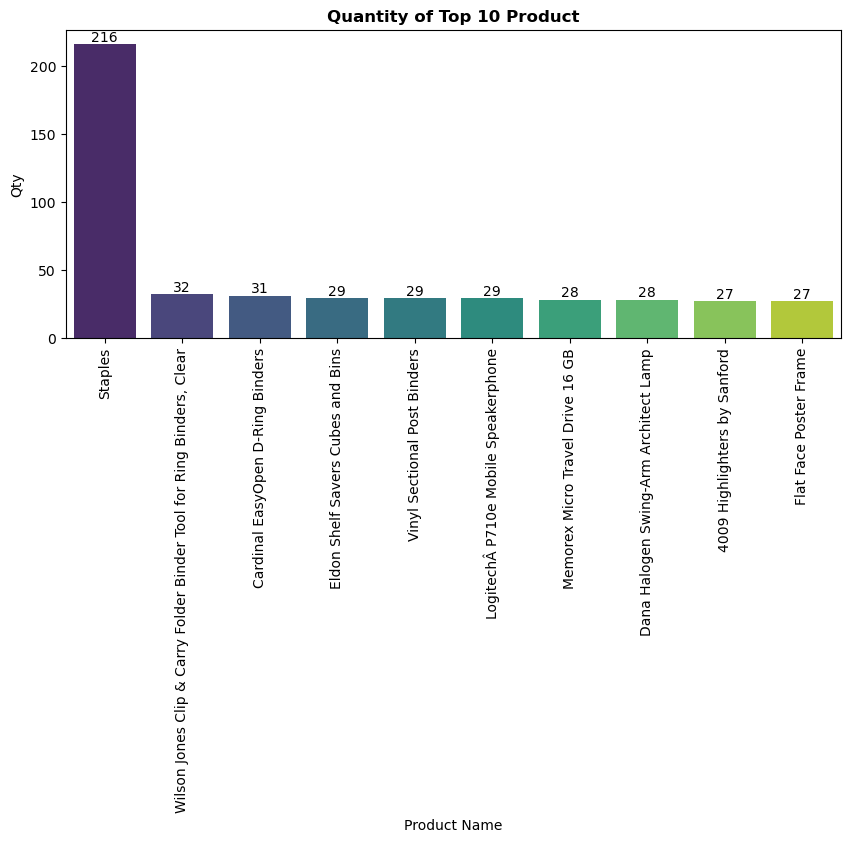

In [14]:
plt.figure(figsize=(10,4))
plt.xticks(rotation= 90)
ax = sns.barplot(data = gr , x = "Product Name" , y = "Qty" , palette="viridis")
for i in ax.containers:
    ax.bar_label(i)
plt.title("Quantity of Top 10 Product" , fontweight= "bold")    
plt.show()

### 3. Which category generates the highest Profit?

In [15]:
gr = df.groupby("Category").agg(Total_Profit=("Profit" , "sum")).round(2)
gr = gr.sort_values(by=["Total_Profit"], ascending=False).head(5).reset_index()
gr

,Category,Total_Profit
0,Copiers,19327.24
1,Accessories,16449.44
2,Binders,16096.80
3,Paper,12119.24
4,Phones,9110.74


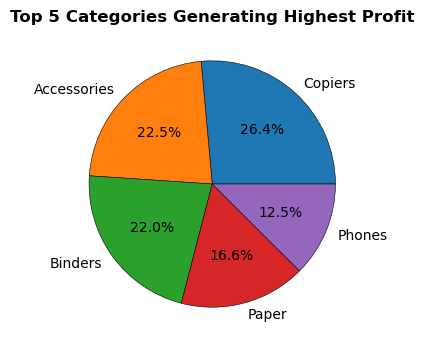

In [16]:
plt.figure(figsize=(6,4))
plt.pie(gr["Total_Profit"], labels=gr["Category"], autopct="%1.1f%%" , wedgeprops= {"edgecolor" : "black" , "linewidth":0.4})
plt.title("Top 5 Categories Generating Highest Profit" , fontweight= "bold")
plt.show()

### 4. State-wise Sales and Profit Analysis

In [17]:
gr = df.groupby("State").agg(Total_Sales=("Sales","sum"), Total_Profit=("Profit","sum")).reset_index().round(2)
gr

,State,Total_Sales,Total_Profit
0,Arizona,35241.67,-3436.46
1,California,457607.73,76346.23
2,Colorado,32108.12,-6527.86
3,Idaho,4382.49,826.72
4,Montana,5589.35,1833.33
5,Nevada,16729.10,3316.77
6,New Mexico,4783.52,1157.12
7,Oregon,17431.15,-1190.47
8,Utah,11220.06,2546.53
9,Washington,138641.27,33402.65


C:\Users\NITIN\AppData\Local\Temp\ipykernel_16528\1958295476.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gr, x ="State", y="Total_Sales",palette="viridis")


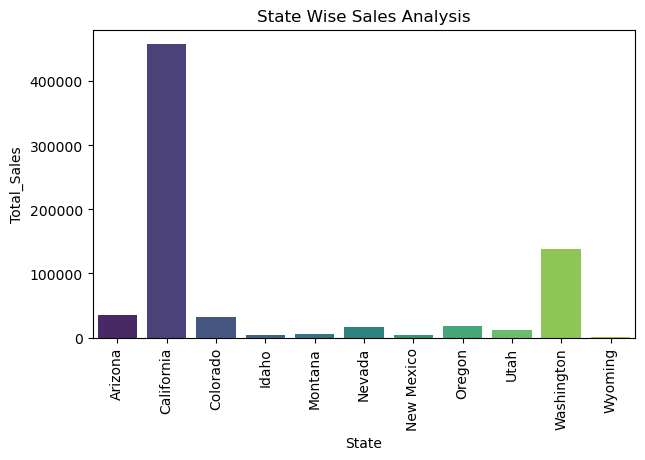

C:\Users\NITIN\AppData\Local\Temp\ipykernel_16528\1958295476.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gr, x ="State", y="Total_Profit",palette="viridis")


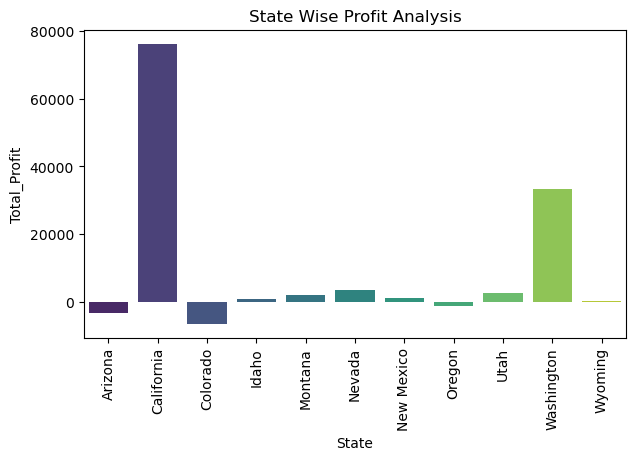

In [18]:
plt.figure(figsize=(7,4))
sns.barplot(data=gr, x ="State", y="Total_Sales",palette="viridis")
plt.xticks(rotation=90)
plt.title("State Wise Sales Analysis")
plt.show()


plt.figure(figsize=(7,4))
sns.barplot(data=gr, x ="State", y="Total_Profit",palette="viridis")
plt.xticks(rotation=90)
plt.title("State Wise Profit Analysis")
plt.show()

### 5. What is the Monthly Sales Trend?

In [19]:
df["Month_no"] = df["Order Date"].dt.month

In [20]:
df["Month_name"] = df["Order Date"].dt.month_name()

In [21]:
df["Month"] = df["Month_no"].astype(str) + "-" + df["Month_name"]

In [22]:
gr = df.groupby("Month_name").agg(Total_Sales=("Sales","sum")).round(2)
gr

,Total_Sales
Month_name,
April,41943.02
August,62674.33
December,115934.54
February,16268.62
January,24918.62
July,64690.13
June,48519.55
March,73023.74
May,45320.87


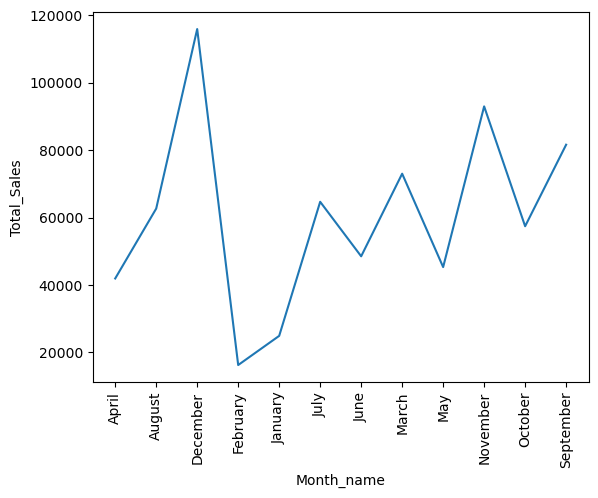

In [23]:
plt.xticks(rotation=90)
sns.lineplot(data = gr ,x = "Month_name" , y = "Total_Sales")
plt.show()

### 6. What is the Year-wise performance of Sales and Profit?

In [24]:
df["Year"] = df["Order Date"].dt.year

In [25]:
gr = df.groupby("Year").agg(Total_Sales=("Sales","sum"), Total_Profit=("Profit","sum")).reset_index().round(2)
gr

,Year,Total_Sales,Total_Profit
0,2019,147883.03,20065.69
1,2020,139886.35,20457.04
2,2021,186935.69,23951.40
3,2022,250632.53,43900.63


<Figure size 2000x300 with 0 Axes>

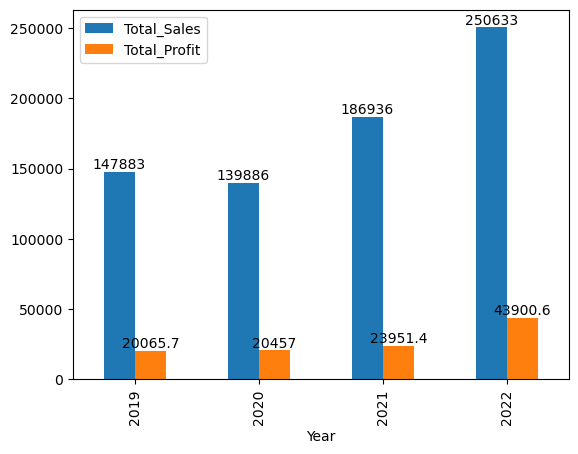

In [26]:
plt.figure(figsize=(20,3))
ax = gr.set_index("Year")[["Total_Sales" , "Total_Profit"]].plot(kind="bar",stacked=False)
for container in ax.containers:
    ax.bar_label(container)
plt.show()    

### 7. Which top 10 customers placed the highest number of orders?

In [27]:
gr = df.groupby("EmailID").agg({"Order ID":"count"})
gr = gr.reset_index()
gr = gr.sort_values("Order ID", ascending=False)
gr = gr.head(10)
gr

,EmailID,Order ID
680,WilliamBrown@gmail.com,24
51,ArthurPrichep@gmail.com,23
549,RickWilson@gmail.com,19
264,GregGuthrie@gmail.com,17
684,ZuschussCarroll@gmail.com,16
172,DarrinSayre@gmail.com,16
574,SallyHughsby@gmail.com,15
399,LenaCreighton@gmail.com,15
398,LenaCacioppo@gmail.com,15
214,EdwardHooks@gmail.com,15


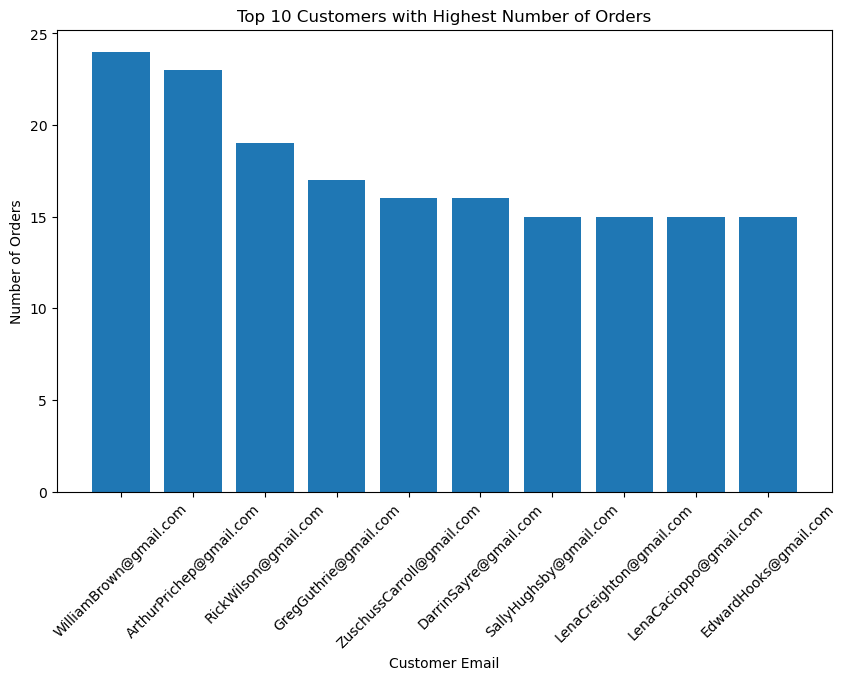

In [28]:
plt.figure(figsize=(10,6))
plt.bar(gr["EmailID"], gr["Order ID"])
plt.title("Top 10 Customers with Highest Number of Orders")
plt.xlabel("Customer Email")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

### 8. Which products have negative profit (loss-making)?

In [29]:
gr = df.groupby("Product Name").agg({"Profit" : "sum"}).round(2)
gr = gr[gr["Profit"]<0]

In [30]:
gr

,Profit
Product Name,
Acco Expandable Hanging Binders,-6.12
"Acco PRESSTEX Data Binder with Storage Hooks, Dark Blue, 9 1/2"" X 11""",-4.52
Acco Perma 3000 Stacking Storage Drawers,-1.26
"Acco Recycled 2"" Capacity Laser Printer Hanging Data Binders",-9.97
Acco Side-Punched Conventional Columnar Pads,-2.60
...,...
Wilson Jones DublLock D-Ring Binders,-1.35
Zebra GK420t Direct Thermal/Thermal Transfer Printer,-938.28
i.Sound Portable Power - 8000 mAh,-60.41


### 9. What is the Average Order Value (AOV)?

In [31]:
gr = df.groupby("Order ID").agg(Total_Sales=("Sales","sum")).round(2)
gr

,Total_Sales
Order ID,
CA-2019-100090,699.19
CA-2019-100363,21.38
CA-2019-100860,18.75
CA-2019-100867,321.55
CA-2019-100881,302.38
...,...
US-2022-163657,255.25
US-2022-163790,1158.88
US-2022-166688,1196.32


In [32]:
print("Average Order value is:" ,gr["Total_Sales"].mean().round(2))

Average Order value is: 450.8


### 10. How many repeat customers do we have?

In [33]:
gr = df.groupby("EmailID").agg(Customer_count=("EmailID" , "count"))
gr = gr[gr["Customer_count"] >1]
gr = gr.sort_values(by="Customer_count", ascending=False).reset_index()
gr

,EmailID,Customer_count
0,WilliamBrown@gmail.com,24
1,ArthurPrichep@gmail.com,23
2,RickWilson@gmail.com,19
3,GregGuthrie@gmail.com,17
4,ZuschussCarroll@gmail.com,16
...,...,...
571,RicardoSperren@gmail.com,2
572,RandyFerguson@gmail.com,2
573,JackGarza@gmail.com,2
574,JanetLee@gmail.com,2


### 11. Show top 10  categories which sells the most quantity?

In [34]:
gr = df.groupby("Category").agg(Qty_Ordered=("Quantity","sum"))
gr = gr.reset_index()
gr = gr.sort_values("Qty_Ordered", ascending=False)
gr = gr.head(10)
gr

,Category,Qty_Ordered
3,Binders,1868
12,Paper,1702
9,Furnishings,1170
13,Phones,1066
14,Storage,1037
0,Accessories,1030
2,Art,926
5,Chairs,734
1,Appliances,492
16,Tables,481


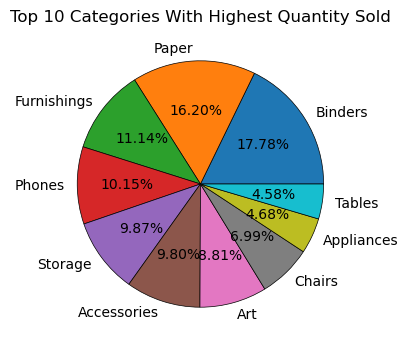

In [35]:
plt.figure(figsize=(8,4))
plt.pie(gr["Qty_Ordered"],labels=gr["Category"],autopct="%1.2f%%",wedgeprops={"edgecolor":"black","linewidth":0.5})
plt.title("Top 10 Categories With Highest Quantity Sold")
plt.show()

### 12. Calculate Profit Margin % for each product?

In [36]:
gr = df.groupby("Product Name").agg({"Profit":"sum" , "Sales":"sum"})
gr["Profit_Margin"] = ((gr["Profit"] / gr["Sales"])*100).round(2)
gr = gr.sort_values("Profit_Margin", ascending=False).head(10)
gr = gr.reset_index()
gr

,Product Name,Profit,Sales,Profit_Margin
0,"""While you Were Out"" Message Book, One Form pe...",3.710,7.42,50.0
1,OIC Binder Clips,32.220,64.44,50.0
2,White Business Envelopes with Contemporary Sea...,49.230,98.46,50.0
3,Tops Green Bar Computer Printout Paper,73.410,146.82,50.0
4,Avery 505,37.000,74.00,50.0
5,Avery 490,37.000,74.00,50.0
6,Southworth Structures Collection,25.480,50.96,50.0
7,Avery 475,66.600,133.20,50.0
8,Xerox 1916,122.350,244.70,50.0
9,Recycled Interoffice Envelopes with String and...,35.985,71.97,50.0


### 13. Which is the most profitable month?

In [37]:
gr = df.groupby("Month_name").agg(Total_Profit=("Profit","sum")).round(2)
gr = gr.sort_values(by="Total_Profit" , ascending=False).head(5).reset_index()
gr

,Month_name,Total_Profit
0,March,16094.88
1,September,14694.86
2,December,13258.62
3,November,13095.06
4,August,11077.61


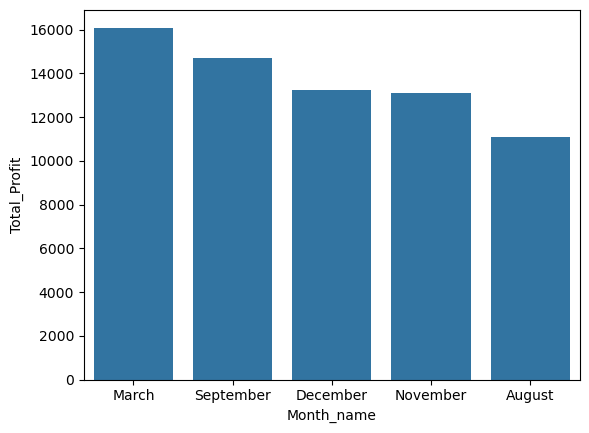

In [38]:
sns.barplot(data = gr, x = "Month_name" , y = "Total_Profit")
plt.show()

### 14. What is the average shipping time?

In [39]:
df["Shipping Time"]= (df["Ship Date"] - df["Order Date"]).dt.days


In [40]:
df["Shipping Time"].mean()

np.float64(3.928125)

### 15. Does Shipping Time impact Profit? (Correlation Analysis)

In [41]:
df[["Shipping Time" , "Profit"]].corr()

,Shipping Time,Profit
Shipping Time,1.000000,-0.028511
Profit,-0.028511,1.000000


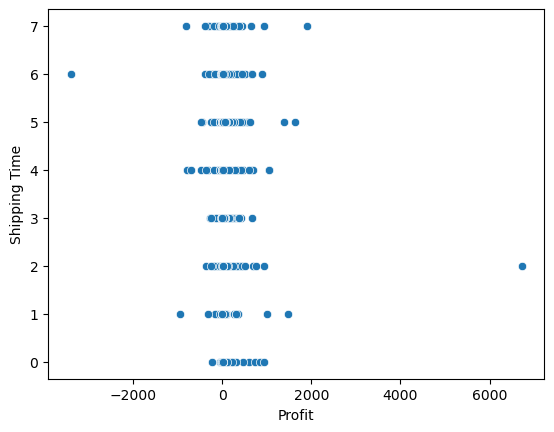

In [42]:
sns.scatterplot(data = df , x = "Profit" , y = "Shipping Time")
plt.show()

## 📈 Conclusion

In conclusion, this project on Amazon Sales Data Analysis provides a clear understanding of overall business performance using data-driven techniques. The dataset obtained from Kaggle was analyzed using Python to extract meaningful insights related to sales, profit, customer behavior, and regional performance.

The analysis revealed important patterns such as top-performing product categories, variations in sales across different states, and trends over time. It was also observed that higher sales do not always result in higher profit, highlighting the importance of cost and pricing strategies. Additionally, customer analysis helped in identifying repeat customers and high-value buyers, which are crucial for business growth.

The use of visualizations like bar graphs made it easier to interpret complex data and compare different segments effectively. These insights can help businesses improve decision-making, optimize strategies, and focus on high-performing areas.

Overall, this project enhanced my practical knowledge of Python, data analysis, and data visualization, and demonstrated how raw data can be transformed into meaningful insights for better business outcomes.